# How does StackingClassifier works ?

> - sklearn's `StackingClassifier` does:
>   - Train base learners: xgb_clf, lgbm_clf on the original training set.
>   - Use k-fold cross-validation (cv=5):
>     - For each fold, it:
>     - Trains base learners on k-1 folds.
>     - Predicts probabilities for the held-out fold.
>     - This gives out-of-fold predictions from each base model → used as new features.
>   - Train meta-learner (LogisticRegression):
>     - On the out-of-fold predictions from base models.
>     - Learns to combine the base models.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Create a synthetic classification dataset
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5, 
    n_redundant=2, weights=[0.85, 0.15], random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Initialize base models
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

In [2]:
# Prepare arrays for out-of-fold and test predictions
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_xgb = np.zeros(len(X_train))
oof_preds_rf = np.zeros(len(X_train))
test_preds_xgb = np.zeros(len(X_test))
test_preds_rf = np.zeros(len(X_test))

# Generate out-of-fold predictions
for train_idx, val_idx in kf.split(X_train):
    # get training and validation set
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # train base learner on training set
    xgb.fit(X_tr, y_tr)
    rf.fit(X_tr, y_tr)
    
    # extract probabilities of class 1. These stored as new meta-features for the meta-model
    oof_preds_xgb[val_idx] = xgb.predict_proba(X_val)[:, 1]
    oof_preds_rf[val_idx] = rf.predict_proba(X_val)[:, 1]

    # adding contribution to predictions on test set by model trained in each fold
    test_preds_xgb += xgb.predict_proba(X_test)[:, 1] / kf.n_splits
    test_preds_rf += rf.predict_proba(X_test)[:, 1] / kf.n_splits

## without meta-learner

In [3]:
# Simple average
avg_preds_proba = (test_preds_xgb + test_preds_rf) / 2
avg_preds_label = (avg_preds_proba >= 0.5).astype(int)

# Evaluation
print("Averaging Ensemble:")
print("ROC AUC:", roc_auc_score(y_test, avg_preds_proba))
print(classification_report(y_test, avg_preds_label))

Averaging Ensemble:
ROC AUC: 0.9874021759877839
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       169
           1       0.96      0.81      0.88        31

    accuracy                           0.96       200
   macro avg       0.96      0.90      0.93       200
weighted avg       0.96      0.96      0.96       200



## with meta-learner

In [4]:
# Train meta-learner on OOF predictions
X_meta_train = np.column_stack((oof_preds_xgb, oof_preds_rf))
X_meta_test = np.column_stack((test_preds_xgb, test_preds_rf))

meta_learner = LogisticRegression()
meta_learner.fit(X_meta_train, y_train)
final_preds = meta_learner.predict(X_meta_test)
final_proba = meta_learner.predict_proba(X_meta_test)[:, 1]

# Evaluate
print("Classification Report:\n", classification_report(y_test, final_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, final_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       169
           1       0.96      0.81      0.88        31

    accuracy                           0.96       200
   macro avg       0.96      0.90      0.93       200
weighted avg       0.96      0.96      0.96       200

ROC-AUC Score: 0.9881656804733727


# What is PCA ?

> - Projects data to a new space using orthogonal axes (principal components) with the highest variance.
> - It is used when features are correlated.

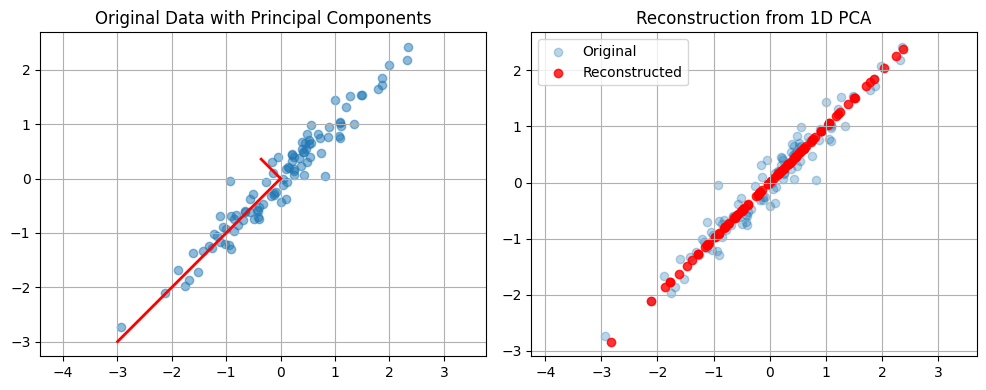

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Generate a simple 2D dataset
np.random.seed(42)
X = np.random.randn(100, 2)
X[:, 1] = 0.5 * X[:, 0] + 0.1 * np.random.randn(100)  # Add correlation

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize original data and principal components
plt.figure(figsize=(10, 4))

# Original data
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.5)
origin = np.mean(X_scaled, axis=0)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    plt.plot([origin[0], origin[0]+v[0]], [origin[1], origin[1]+v[1]], 'r', linewidth=2)
plt.title("Original Data with Principal Components")
plt.axis('equal')
plt.grid(True)

# Step 5: Reduce to 1D and reconstruct back
### Helps to see how much information is lost when reducing dimensions.
pca_1d = PCA(n_components=1)
X_pca_1d = pca_1d.fit_transform(X_scaled) # projecting 2D data onto 1D space
X_reconstructed = pca_1d.inverse_transform(X_pca_1d) # maps 1D data back to original 2D space

# Visualize reconstruction
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, label='Original')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.8, label='Reconstructed', color='red')
plt.title("Reconstruction from 1D PCA")
plt.legend()
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()


**Key Points**
> - Red arrows show the new axes PCA finds
> - The first PC captures the most variance direction
> - Even reducing 2D data to 1D still retains most of the variance
> - Reconstruction shows what we'll lose when we go from high dimension → low → back

# What is Encoding ?

> - refers to converting categorical data into numerical form.
> - Common Encoding Techniques
>   - Label Encoding
>   - One-Hot Encoding
>   - Target Encoding

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red', 'Green']})

# Label Encoding
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Color'])

# One-Hot Encoding
df_onehot = pd.get_dummies(df['Color'], prefix='Color')

print("Original + Label:\n", df)
print("\nOne-hot Encoded:\n", df_onehot)

Original + Label:
    Color  Label
0    Red      2
1   Blue      0
2  Green      1
3    Red      2
4  Green      1

One-hot Encoded:
    Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4       False         True      False


**Target Encoding**
> - It is a technique where we replace each category with the mean value of the target variable for that category.
> - This works only for supervised problems (classification/regression), and is especially useful when you have high-cardinality categorical variables.

In [7]:
import pandas as pd

# Sample data
df = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Bangalore', 'Mumbai', 'Delhi'],
    'Purchased': [1, 0, 1, 0, 1, 0]
})

print(df)
print("\n")

# Calculate mean of target for each category
target_mean = df.groupby('City')['Purchased'].mean()

# Map to new column
df['City_encoded'] = df['City'].map(target_mean)

print(df)

        City  Purchased
0      Delhi          1
1     Mumbai          0
2      Delhi          1
3  Bangalore          0
4     Mumbai          1
5      Delhi          0


        City  Purchased  City_encoded
0      Delhi          1      0.666667
1     Mumbai          0      0.500000
2      Delhi          1      0.666667
3  Bangalore          0      0.000000
4     Mumbai          1      0.500000
5      Delhi          0      0.666667


# What is difference between Type I and Type II error ? 

| Error Type        | What It Means                                 | Alternate Names    |
| ----------------- | --------------------------------------------- | ------------------ |
| **Type I Error**  | Rejecting a **true null hypothesis**          | **False Positive** |
| **Type II Error** | Failing to reject a **false null hypothesis** | **False Negative** |


> - Type I --> False Alarm
> - Type II --> Missed Detection

# Python Coding Questions

>  ["a","a","b","b","a","a"] -->  ["a",2,"b",2, "a",2]

In [8]:
input_list = ["a","a","b","b","a","a"]
# desired output --> ["a", 2, "b", 2, "a", 2]
# input_list = ["a"]

final_list = []
prev_elem = None
dup_count = 0

for i, elem in enumerate(input_list):
    print("At start of iteration {}, final_list: {}".format(i+1, final_list))
    print("\tNew element: {} at index {}".format(elem, i))

    # If the current element is the same as the previous one, increase the duplicate count
    if elem == prev_elem:
        dup_count = dup_count + 1
        print("\tDuplicate count for element {} : {}".format(elem, dup_count))
    else:
        # If it's a new element and not the first one
        if prev_elem is not None:
            # Add the previous element to the final list
            final_list.append(prev_elem)
            if dup_count > 0:
                # If it was repeated, add the count (including the first occurrence)
                final_list.append(dup_count+1)
        # Reset the duplicate count for the new element
        dup_count = 0
        prev_elem = elem
    
    # condition for last element of the list
    if len(input_list) == i+1:
        # Add the last element
        final_list.append(elem)
        # If it was repeated, add the count
        if dup_count > 0:
            final_list.append(dup_count+1)
    
    print("At end of iteration {}, final_list: {}\n".format(i+1, final_list))

At start of iteration 1, final_list: []
	New element: a at index 0
At end of iteration 1, final_list: []

At start of iteration 2, final_list: []
	New element: a at index 1
	Duplicate count for element a : 1
At end of iteration 2, final_list: []

At start of iteration 3, final_list: []
	New element: b at index 2
At end of iteration 3, final_list: ['a', 2]

At start of iteration 4, final_list: ['a', 2]
	New element: b at index 3
	Duplicate count for element b : 1
At end of iteration 4, final_list: ['a', 2]

At start of iteration 5, final_list: ['a', 2]
	New element: a at index 4
At end of iteration 5, final_list: ['a', 2, 'b', 2]

At start of iteration 6, final_list: ['a', 2, 'b', 2]
	New element: a at index 5
	Duplicate count for element a : 1
At end of iteration 6, final_list: ['a', 2, 'b', 2, 'a', 2]

